In [693]:
import pyspedas
import pytplot
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.cm as cm
# %matplotlib tk

import scipy
from scipy import interpolate,optimize
from scipy.optimize import curve_fit
from skimage.transform import probabilistic_hough_line

import helper
from helper import UTC_to_UNX
from helper import find_closest_index_dt

import dateutil
from dateutil.parser import parse

import math
from scipy.interpolate import interp1d

In [699]:
start = '2023-01-03'
end = '2023-01-04'
time_clip = True
no_update = False
varnames_hfr = 'psp_fld_l3_rfs_hfr_auto_averages_ch0_V1V2'
varnames_lfr = 'psp_fld_l3_rfs_lfr_auto_averages_ch0_V1V2'
rfs_hfr_vars = pyspedas.psp.fields(trange=[start, end], datatype='rfs_hfr', level='l3', no_update=no_update, varnames=varnames_hfr)
rfs_lfr_vars = pyspedas.psp.fields(trange=[start, end], datatype='rfs_lfr', level='l3', no_update=no_update, varnames=varnames_lfr)
rfs_ch0_hfr = pyspedas.get('psp_fld_l3_rfs_hfr_auto_averages_ch0_V1V2')
rfs_ch0_lfr = pyspedas.get('psp_fld_l3_rfs_lfr_auto_averages_ch0_V1V2')
data_hfr = rfs_ch0_hfr.y
freq_hfr = rfs_ch0_hfr.v
times_hfr = rfs_ch0_hfr.times

data_lfr = rfs_ch0_lfr.y
freq_lfr = rfs_ch0_lfr.v
times_lfr = rfs_ch0_lfr.times

dyspec = data_hfr
t_fits = times_hfr
full_f_fits = np.concatenate((freq_lfr[0], freq_hfr[0]))
full_data = np.concatenate((data_lfr, data_hfr), axis = 1)

29-Oct-25 13:56:38: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_hfr/2023/
29-Oct-25 13:56:38: File is current: psp_data/fields/l3/rfs_hfr/2023/psp_fld_l3_rfs_hfr_20230103_v03.cdf
29-Oct-25 13:56:38: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_hfr/2023/
29-Oct-25 13:56:39: File is current: psp_data/fields/l3/rfs_hfr/2023/psp_fld_l3_rfs_hfr_20230103_v03.cdf
29-Oct-25 13:56:39: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/2023/
29-Oct-25 13:56:39: File is current: psp_data/fields/l3/rfs_lfr/2023/psp_fld_l3_rfs_lfr_20230103_v03.cdf
29-Oct-25 13:56:39: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/2023/
29-Oct-25 13:56:40: File is current: psp_data/fields/l3/rfs_lfr/2023/psp_fld_l3_rfs_lfr_20230103_v03.cdf


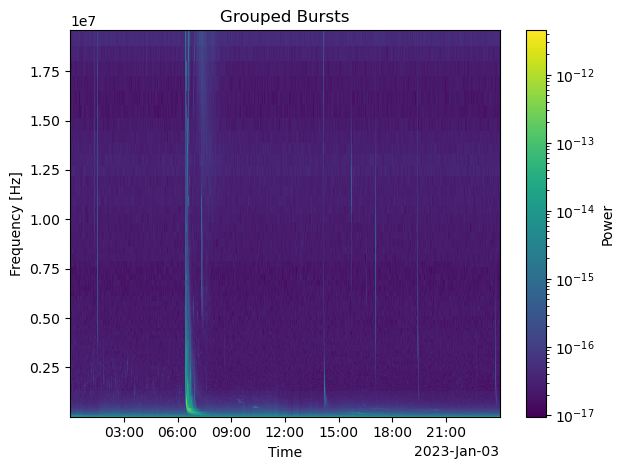

In [705]:
fig, ax = plt.subplots()
p = ax.pcolormesh(times_hfr, full_f_fits, full_data.T, norm=LogNorm())
plt.colorbar(p, label='Power')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

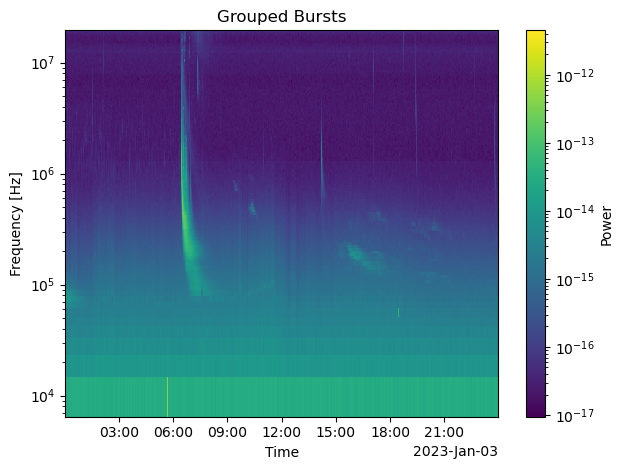

In [7]:
fig, ax = plt.subplots()
p = ax.pcolormesh(times_hfr, full_f_fits, full_data.T, norm=LogNorm())
plt.colorbar(p, label='Power')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
def bmap_row_mean_loop(full_data, ratio=1.2):
    freq_num = full_data.shape[1]
    bmap = np.zeros_like(full_data)

    for i in range(freq_num):
        row_avg = np.mean(full_data[:, i])
        row_std = np.std(full_data[:, i])
        bmap[:, i] = (full_data[:, i] > ratio * (row_avg + row_std))

    return bmap

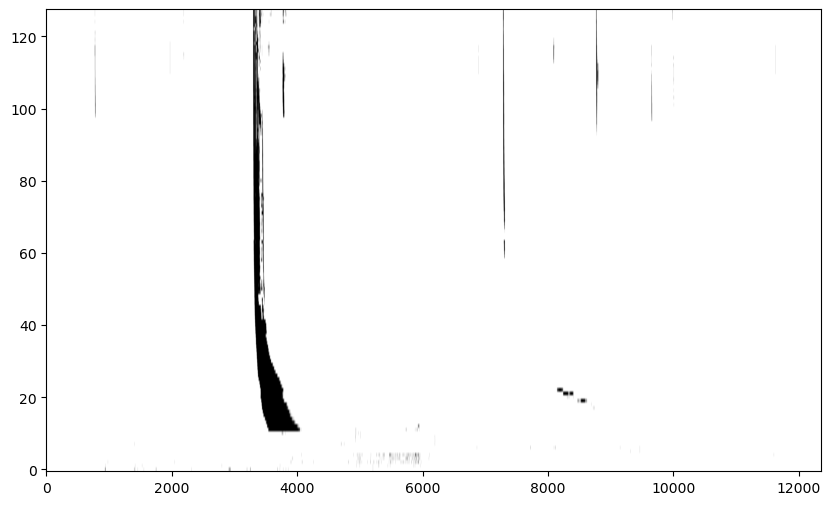

In [11]:
bmap_row_mean = bmap_row_mean_loop(full_data)

plt.figure(figsize=(10, 6))
plt.imshow(1-bmap_row_mean.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

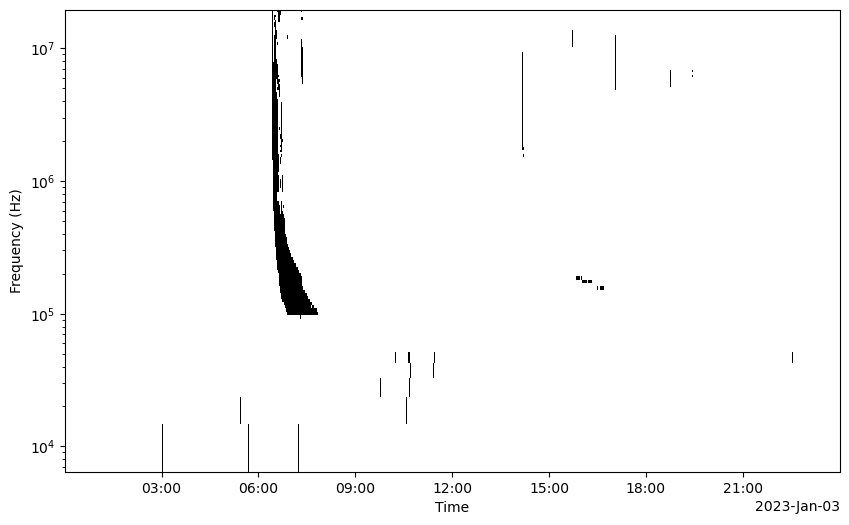

In [13]:
fig, ax = plt.subplots(figsize=(10,6))
pm = ax.pcolormesh(times_hfr, full_f_fits, bmap_row_mean.T, shading='auto', cmap='gray_r', vmin=0, vmax=1)
ax.set_xlabel('Time')
ax.set_ylabel('Frequency (Hz)')
ax.set_yscale('log')
plt.show()

In [15]:
def hough_detect(bmap,dyspec,threshold=50,line_gap=10,line_length=25,
            theta=np.linspace(np.pi/2-np.pi/8,np.pi/2-1/180*np.pi,300)):
    # trial 4
    threshold = 130
    line_gap = 110
    line_length = 110
    theta = np.deg2rad(np.linspace(45, 55, 120))
    
    # trial 3
    # threshold = 50
    # line_gap = 110
    # line_length = 110
    # theta = np.deg2rad(np.linspace(65, 75, 120))
    lines = probabilistic_hough_line(bmap, threshold=threshold,line_gap=line_gap,line_length=line_length,
                                 theta=theta)
    return lines

norm = np.linalg.norm
def point_to_line_distance(p1,p2,p3):
    d = np.abs(norm(np.cross(p2-p1, p1-p3)))/norm(p2-p1)
    return d

def point_to_point_distance(p1,p2):
    return norm(p1-p2)

lines = hough_detect(bmap_row_mean, full_data)
lines

[((17, 3450), (127, 3340)),
 ((17, 3451), (127, 3341)),
 ((17, 3447), (127, 3337)),
 ((17, 3448), (127, 3338)),
 ((17, 3449), (127, 3339)),
 ((17, 3452), (127, 3342)),
 ((16, 3458), (126, 3348)),
 ((16, 3460), (126, 3350)),
 ((16, 3459), (126, 3349)),
 ((16, 3469), (127, 3358)),
 ((16, 3468), (126, 3358)),
 ((15, 3468), (127, 3356)),
 ((15, 3467), (127, 3355))]

In [17]:
lines[0]

((17, 3450), (127, 3340))

In [59]:
def line_grouping_new(lines, time_diff=5, freq_diff=20):
    lines = sorted(lines, key=lambda line: (line[0][0]))
    line_avg = lines[0]
    line_sets = [line_avg]
    for line in lines:
        in_group = False
        for idx, line_avg in enumerate(line_sets):
            if ((abs(line_avg[0][0] - line[0][0]) < time_diff) and (abs(line_avg[0][1] - line[0][1]) < freq_diff) 
                and (abs(line_avg[1][0] - line[1][0]) < time_diff) and (abs(line_avg[1][1] - line[1][1]) < freq_diff)):
                in_group = True
                line_avg = (
                    (round((line_avg[0][0] + line[0][0]) / 2), round((line_avg[0][1] + line[0][1]) / 2)),
                    (round((line_avg[1][0] + line[1][0]) / 2), round((line_avg[1][1] + line[1][1]) / 2))
                )
                line_sets[idx] = line_avg
                # line_avg[0][0] = (line_avg[0][0] + line[0][0])/2
                # line_avg[0][1] = (line_avg[0][1] + line[0][1])/2
                # line_avg[1][0] = (line_avg[1][0] + line[1][0])/2
                # line_avg[1][1] = (line_avg[1][1] + line[1][1])/2
            break
        if in_group == False:
            line_sets.append(line)
        
    return line_sets

line_sets = line_grouping_new(lines)
line_sets

[((16, 3450), (126, 3340))]

In [25]:
def line_grouping(lines,min_dist=3, threshmode=2): # pix
    """
    Parameters
    ----------
    lines : list
        list of lines detected by hough transform.
    min_dist : float, optional  # pix
        minimum distance between two lines to be grouped together.
    threshmode : int, optional
        DESCRIPTION. 1: only distance of point to line
                        2: distance of point to line and angle between lines
    """
    # group the detected lines into group in regard of events
    lines = sorted(lines, key=lambda i: (i[0][1]+i[1][1])/2)
    line_sets = [[lines[0]]]
    for idx,line in enumerate(lines[0:-1]):
        (A,B),(C,D) = np.array([lines[idx], lines[idx+1] ])

        # use the longer line as the reference
        l_AB = norm(A-B)
        l_CD = norm(C-D)
        if l_AB<l_CD:
            A,B,C,D = C,D,A,B
        
        # point to line distance
        Line_dist_thresh = np.min([point_to_line_distance(A,B,C),point_to_line_distance(A,B,D)])< min_dist
        Line_dist_thresh2 = np.min([point_to_line_distance(A,B,C),point_to_line_distance(A,B,D)])< min_dist*1.5

        # two lines segment not too far away
        Point_dist_thresh = np.min([point_to_point_distance(A,C),point_to_point_distance(A,D),
                                    point_to_point_distance(B,C),point_to_point_distance(B,D)])< np.max(
                                        [point_to_point_distance(A,B),point_to_point_distance(C,D)])
       
        if threshmode==1:
            final_thresh = Line_dist_thresh
        elif threshmode==2:
            final_thresh = Line_dist_thresh & Point_dist_thresh
        elif threshmode==3:
            if B[0]>C[0] and B[1]>C[1]:
                final_thresh = Line_dist_thresh2 & Point_dist_thresh

        if final_thresh:
            # the line join
            line_sets[len(line_sets)-1].append(lines[idx+1])
        else:
            # new set
            line_sets.append([lines[idx+1]])
    
    return line_sets
    
line_sets = line_grouping(lines)
line_sets

[[((17, 3447), (127, 3337)),
  ((17, 3448), (127, 3338)),
  ((17, 3449), (127, 3339)),
  ((17, 3450), (127, 3340)),
  ((17, 3451), (127, 3341)),
  ((17, 3452), (127, 3342))],
 [((16, 3458), (126, 3348)),
  ((16, 3459), (126, 3349)),
  ((16, 3460), (126, 3350))],
 [((15, 3467), (127, 3355)),
  ((15, 3468), (127, 3356)),
  ((16, 3468), (126, 3358)),
  ((16, 3469), (127, 3358))]]

In [27]:
type(line_sets)

list

<Figure size 1000x600 with 0 Axes>

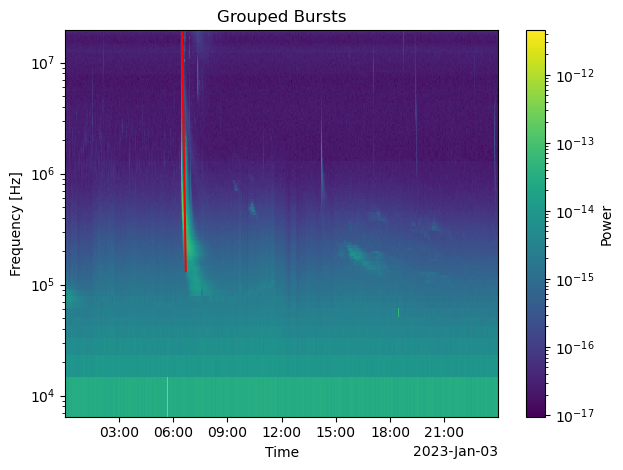

In [63]:
plt.figure(figsize=(10, 6))

fig, ax = plt.subplots()
p = ax.pcolormesh(times_hfr, full_f_fits, full_data.T, norm=LogNorm())
plt.colorbar(p, label='Power')

for (x0, y0), (x1, y1) in line_sets:
    t0, t1 = t_fits[y0], t_fits[y1]
    f0, f1 = full_f_fits[x0], full_f_fits[x1]
    # print(t0, t1, f0, f1)
    ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

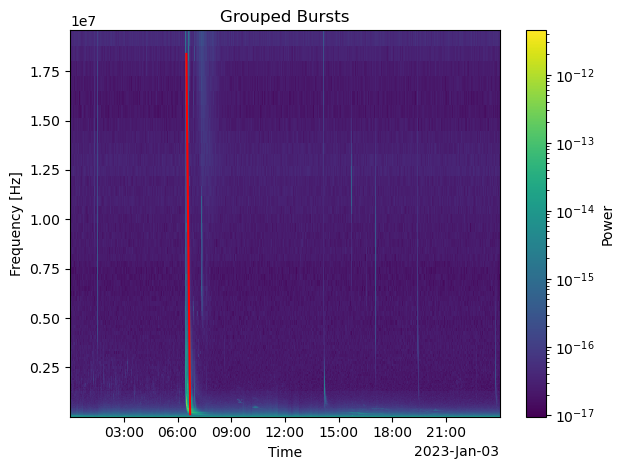

In [69]:
plt.figure(figsize=(10, 6))

fig, ax = plt.subplots()
p = ax.pcolormesh(times_hfr, full_f_fits, full_data.T, norm=LogNorm())
plt.colorbar(p, label='Power')

for (x0, y0), (x1, y1) in line_sets:
    t0, t1 = t_fits[y0], t_fits[y1]
    f0, f1 = full_f_fits[x0], full_f_fits[x1]
    # print(t0, t1, f0, f1)
    ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

In [65]:
def get_info_from_linegroup(line_sets,t_fits,f_fits):

    # mapping from t and f to index of x and y
    t_idx_arr = np.arange(0, t_fits.shape[0])
    f_idx_arr = np.arange(0, f_fits.shape[0])
    t_interf = interpolate.interp1d(t_idx_arr, t_fits)
    f_interf = interpolate.interp1d(f_idx_arr, f_fits)
    
    v_beam = []
    f_range_burst = []
    t_range_burst = []
    model_curve_set = []
    t_set_arr_set = []
    f_set_arr_set = []
    t_set_arr = []
    f_set_arr = []
    t_model_arr = []
    f_model_arr = []

    for lines in line_sets:
        if len(lines)==1:
            continue
        # try:
            x_set=[]
            y_set=[]
            for line in lines:
                x_set.append(line[0][1])
                x_set.append(line[1][1])
                y_set.append(line[0][0])
                y_set.append(line[1][0])

            print(x_set)
            print(y_set)

            t_set_arr = (t_interf(x_set) - np.min(t_fits))*24*3600
            f_set_arr = f_interf(y_set)

            popt, pcov = optimize.curve_fit(rt.freq_drift_f_t,
                t_set_arr, f_set_arr, p0=(0.1,np.min(t_set_arr)-3./3600/24), method="lm")

            t_model_arr  = np.linspace(rt.freq_drift_t_f(np.min(f_set_arr),*popt) ,
                                       rt.freq_drift_t_f(np.max(f_set_arr),*popt),50) 
            f_model_arr = rt.freq_drift_f_t(t_model_arr,popt[0],popt[1])

            t_model_arr = t_model_arr/(24*3600)+np.min(t_fits)


            model_curve_set.append([t_model_arr,f_model_arr])
            t_range_burst.append( [rt.freq_drift_t_f(np.min(f_set_arr),*popt)[0]/(24*3600)+np.min(t_fits) ,
                                   rt.freq_drift_t_f(np.max(f_set_arr),*popt)[0]/(24*3600)+np.min(t_fits) ] )
            f_range_burst.append([np.min(f_set_arr),np.max(f_set_arr)])
            v_beam.append(popt[0])
            t_set_arr_set.append(t_set_arr)
            f_set_arr_set.append(f_set_arr)
        # except:
            print('pass')
            pass

    
    return (v_beam, f_range_burst, t_range_burst, model_curve_set,
            t_set_arr_set,f_set_arr_set,
           t_model_arr,f_model_arr)

In [67]:
(v_beam, f_range_burst, t_range_burst, model_curve_set, t_set_arr_set,f_set_arr_set, 
     t_model_arr,f_model_arr) = get_info_from_linegroup(line_sets,t_fits,full_f_fits)
v_beam, f_range_burst, t_range_burst, model_curve_set, t_set_arr_set,f_set_arr_set, t_model_arr,f_model_arr

([], [], [], [], [], [], [], [])

In [71]:
import numpy as np
import numpy.linalg as LA
from scipy.interpolate import interp2d
from scipy.ndimage.filters import gaussian_filter
import numpy.linalg as LA

def PJcurvature(x,y):
    """
    input  : the coordinate of the three point
    output : the curvature and norm direction
    refer to https://github.com/peijin94/PJCurvature for detail
    """
    t_a = LA.norm([x[1]-x[0],y[1]-y[0]])
    t_b = LA.norm([x[2]-x[1],y[2]-y[1]])

    M = np.array([
        [1, -t_a, t_a**2],
        [1, 0,    0     ],
        [1,  t_b, t_b**2]])

    a = np.matmul(LA.pinv(M),x)
    b = np.matmul(LA.pinv(M),y)

    kappa = 2*(a[2]*b[1]-b[2]*a[1])/(a[1]**2.+b[1]**2.)**(1.5)
    return kappa, [b[1],-a[1]]/np.sqrt(a[1]**2.+b[1]**2.)


def ACBone(img,x,y,x0,y0,n_iter = 200,d_step=0.2,alpha=25,beta=6000,y_gap=90.,blur_sigma=2.5):
        yy = np.linspace((y0[0]),(y0[1]), int(abs(y0[1]-y0[0])/y_gap))
        xx = np.linspace((x0[0]),(x0[1]), len(yy))# +  np.random.normal(0, 0.1, len(yy))

        blurred = gaussian_filter(img, sigma=blur_sigma)

        Grad_x = interp2d(x, y, np.gradient(img,axis=1)/(np.max(np.gradient(img,axis=1))), kind='quintic')
        Grad_y = interp2d(x, y, np.gradient(img,axis=0)/(np.max(np.gradient(img,axis=0))), kind='quintic')


        Grad_x_blur = interp2d(x, y, np.gradient(blurred,axis=1)/(np.max(np.gradient(blurred,axis=1))), kind='quintic')
        Grad_y_blur = interp2d(x, y, np.gradient(blurred,axis=0)/(np.max(np.gradient(blurred,axis=0))), kind='quintic')

        xx_new = xx
        yy_new = yy

        idx_img=0
        for step in range(n_iter):
            kappa_arr = np.zeros(len(xx))
            norm_arr  = np.zeros([len(xx),2])
            for idx,val in enumerate(xx[1:-1]):
                ytmp = yy_new[idx:idx+3]
                xtmp = xx_new[idx:idx+3]
                kappa,norm_l = PJcurvature(xtmp,ytmp)
                kappa_arr[idx+1] = kappa
                norm_arr[idx+1,:] = norm_l


            f_x = beta* kappa_arr*norm_arr[:,0]
            f_x[-1] = -f_x[-2]
            f_x[0] = -f_x[1]
            if step>n_iter/3.5 :
                xx_new = xx_new+ d_step* (alpha * np.array([Grad_x(xx_new[i],yy_new[i])
                            for i in np.arange(len(xx_new))])[:,0] + f_x)
            else:
                xx_new = xx_new+ d_step* (alpha * np.array([Grad_x_blur(xx_new[i],yy_new[i])
                            for i in np.arange(len(xx_new))])[:,0] + f_x)

            #print(alpha * np.array([Grad_x_blur(xx_new[i],yy_new[i])
            #                for i in np.arange(len(xx_new))])[:,0])
            #yy_new = yy_new+ d_step/1000* (alpha * np.array([Grad_y(xx_new[i],yy_new[i])
            #                                            for i in np.arange(len(xx_new))])[:,0])

        img_xy = interp2d(x, y, img, kind='quintic')
        flux = np.array([img_xy(xx_new[i],yy_new[i])
                            for i in np.arange(len(xx_new))])[:,0]

        return xx_new,yy_new,flux

In [81]:
line_sets[0][0][0]

16

In [95]:
full_f_fits

array([1.0546880e+04, 1.8750000e+04, 2.8125000e+04, 3.7500000e+04,
       4.6875000e+04, 5.6250000e+04, 6.5625000e+04, 7.5000000e+04,
       8.4375000e+04, 8.9062500e+04, 9.4921883e+04, 1.0078125e+05,
       1.0664062e+05, 1.1250000e+05, 1.1835938e+05, 1.2539062e+05,
       1.3242188e+05, 1.4062500e+05, 1.4648438e+05, 1.5703125e+05,
       1.6640625e+05, 1.7578125e+05, 1.8632812e+05, 1.9687500e+05,
       2.0859375e+05, 2.2031250e+05, 2.3320312e+05, 2.4726562e+05,
       2.6132812e+05, 2.7656250e+05, 2.9296875e+05, 3.0937500e+05,
       3.2812500e+05, 3.4687500e+05, 3.6679688e+05, 3.8789062e+05,
       4.1132812e+05, 4.3476562e+05, 4.5937500e+05, 4.8632812e+05,
       5.1445312e+05, 5.4492188e+05, 5.7656250e+05, 6.0937500e+05,
       6.4570312e+05, 6.8203125e+05, 7.2187500e+05, 7.6406250e+05,
       8.0859375e+05, 8.5546875e+05, 9.0468750e+05, 9.5742188e+05,
       1.0136719e+06, 1.0722656e+06, 1.1343750e+06, 1.1964844e+06,
       1.2656250e+06, 1.3125000e+06, 1.3687500e+06, 1.4250000e

In [377]:
freq_log_old = [math.log(freq, 10) for freq in full_f_fits]
freq_log_old

[4.023123999909351,
 4.273001272063737,
 4.449092531119419,
 4.574031267727718,
 4.670941280735775,
 4.7501225267834,
 4.817069316414012,
 4.875061263391699,
 4.926213785839081,
 4.949694881688604,
 4.977366344030862,
 5.00337974065138,
 5.027922649912459,
 5.051152522447381,
 5.073202691856757,
 5.098265040034176,
 5.121959732891232,
 5.148062535455437,
 5.165791302415869,
 5.19598608777262,
 5.221169633790868,
 5.244972548463494,
 5.270278413728264,
 5.294190571133676,
 5.319301291716706,
 5.343039138671492,
 5.367734365817519,
 5.393163744705505,
 5.417186152455973,
 5.441793292377919,
 5.46682129807985,
 5.490485216277643,
 5.516039320750032,
 5.540173000466751,
 5.564425626954261,
 5.588709283183531,
 5.614188405873636,
 5.638255199022858,
 5.662167356428269,
 5.686929386119905,
 5.711345809649934,
 5.736334242297766,
 5.760846392175172,
 5.784884633042611,
 5.810032888259597,
 5.833804274057701,
 5.858462001572238,
 5.883128885139732,
 5.907730380145067,
 5.9322041495282685,
 5.9

In [347]:
# numpy.logspace(start, stop, num=50, endpoint=True, base=10.0, dtype=None, axis=0)
# Return numbers spaced evenly on a log scale.
# In linear space, the sequence starts at base ** start (base to the power of start) and ends with base ** stop

freq_log = np.logspace(np.log10(full_f_fits.min()), np.log10(full_f_fits.max()), len(full_f_fits))
print(freq_log)

[1.05468852e+04 1.11889644e+04 1.18701325e+04 1.25927691e+04
 1.33593987e+04 1.41726997e+04 1.50355133e+04 1.59508538e+04
 1.69219188e+04 1.79521009e+04 1.90449990e+04 2.02044312e+04
 2.14344479e+04 2.27393463e+04 2.41236850e+04 2.55923003e+04
 2.71503228e+04 2.88031954e+04 3.05566925e+04 3.24169401e+04
 3.43904368e+04 3.64840771e+04 3.87051753e+04 4.10614908e+04
 4.35612553e+04 4.62132019e+04 4.90265952e+04 5.20112639e+04
 5.51776349e+04 5.85367700e+04 6.21004044e+04 6.58809878e+04
 6.98917276e+04 7.41466356e+04 7.86605762e+04 8.34493190e+04
 8.85295936e+04 9.39191480e+04 9.96368108e+04 1.05702557e+05
 1.12137576e+05 1.18964351e+05 1.26206730e+05 1.33890014e+05
 1.42041045e+05 1.50688300e+05 1.59861987e+05 1.69594155e+05
 1.79918804e+05 1.90872002e+05 2.02492015e+05 2.14819438e+05
 2.27897337e+05 2.41771399e+05 2.56490094e+05 2.72104842e+05
 2.88670194e+05 3.06244021e+05 3.24887717e+05 3.44666414e+05
 3.65649210e+05 3.87909408e+05 4.11524775e+05 4.36577812e+05
 4.63156042e+05 4.913523

In [337]:
freq_log_exp = np.log10(freq_log)
freq_log_exp

array([4.02312422, 4.04878989, 4.07445557, 4.10012124, 4.12578691,
       4.15145259, 4.17711826, 4.20278393, 4.22844961, 4.25411528,
       4.27978095, 4.30544663, 4.3311123 , 4.35677798, 4.38244365,
       4.40810932, 4.433775  , 4.45944067, 4.48510634, 4.51077202,
       4.53643769, 4.56210337, 4.58776904, 4.61343471, 4.63910039,
       4.66476606, 4.69043173, 4.71609741, 4.74176308, 4.76742875,
       4.79309443, 4.8187601 , 4.84442578, 4.87009145, 4.89575712,
       4.9214228 , 4.94708847, 4.97275414, 4.99841982, 5.02408549,
       5.04975117, 5.07541684, 5.10108251, 5.12674819, 5.15241386,
       5.17807953, 5.20374521, 5.22941088, 5.25507655, 5.28074223,
       5.3064079 , 5.33207358, 5.35773925, 5.38340492, 5.4090706 ,
       5.43473627, 5.46040194, 5.48606762, 5.51173329, 5.53739897,
       5.56306464, 5.58873031, 5.61439599, 5.64006166, 5.66572733,
       5.69139301, 5.71705868, 5.74272435, 5.76839003, 5.7940557 ,
       5.81972138, 5.84538705, 5.87105272, 5.8967184 , 5.92238

In [371]:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.interp1d.html

interpolate_func = interp1d(full_f_fits, full_data[0], kind='linear')

data_log = interp(freq_log)
data_log

array([2.74952350e-14, 2.74951822e-14, 2.74951262e-14, 2.74950668e-14,
       2.74950038e-14, 2.74949369e-14, 2.74948660e-14, 2.74947908e-14,
       2.74947110e-14, 2.74946263e-14, 2.74945382e-14, 2.74944498e-14,
       2.74943560e-14, 2.74942565e-14, 2.74941509e-14, 2.74940390e-14,
       2.74939201e-14, 2.74937909e-14, 2.74936490e-14, 2.74934984e-14,
       2.74933386e-14, 2.74931691e-14, 2.74929832e-14, 2.74927805e-14,
       2.74925655e-14, 2.74923374e-14, 2.74920846e-14, 2.74918127e-14,
       2.74915244e-14, 2.74912056e-14, 2.74908611e-14, 2.74904941e-14,
       2.74900824e-14, 2.74896457e-14, 2.74891599e-14, 2.74886390e-14,
       2.74875804e-14, 2.74865237e-14, 2.74854217e-14, 2.74841936e-14,
       2.74828081e-14, 2.74812576e-14, 2.74797715e-14, 2.74781342e-14,
       2.74763400e-14, 2.74741984e-14, 2.74724246e-14, 2.74702635e-14,
       2.74679036e-14, 2.74653475e-14, 2.74625615e-14, 2.74595881e-14,
       2.74563238e-14, 2.74528771e-14, 2.74491015e-14, 2.74449524e-14,
      

In [703]:
new_full_data = full_data.copy()
for i, data_col in enumerate(full_data):
    interpolate_func = interp1d(full_f_fits, data_col, bounds_error=False)
    data_log = interpolate_func(freq_log)
    new_full_data[i] = data_log

<Figure size 1000x600 with 0 Axes>

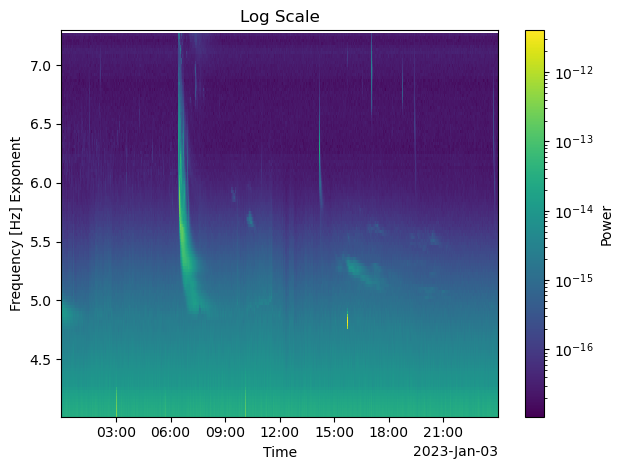

In [379]:
plt.figure(figsize=(10, 6))

fig, ax = plt.subplots()
p = ax.pcolormesh(times_hfr, freq_log_exp, new_full_data.T, norm=LogNorm())
plt.colorbar(p, label='Power')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz] Exponent")
# plt.yscale('log')
plt.title("Log Scale")
# plt.grid(True)
plt.tight_layout()
plt.show()

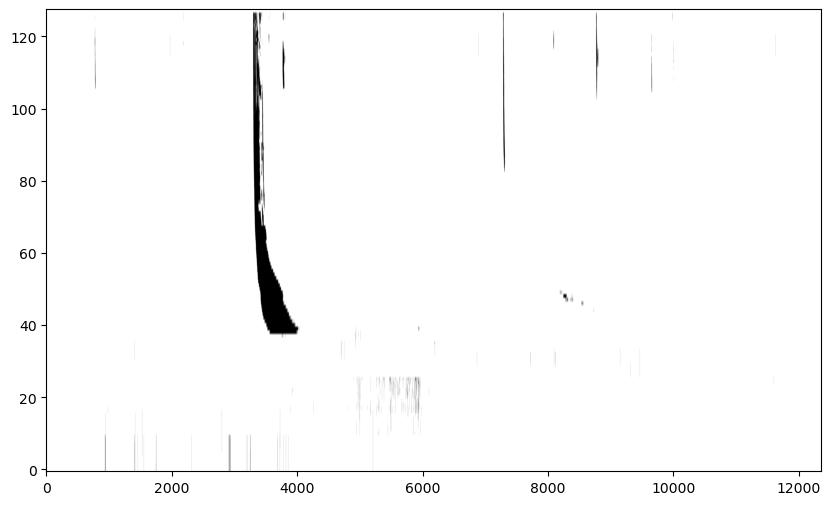

In [391]:
bmap_row_mean = bmap_row_mean_loop(new_full_data, 1.2)

plt.figure(figsize=(10, 6))
plt.imshow(1-bmap_row_mean.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

In [689]:
def hough_detect(bmap,dyspec,threshold=50,line_gap=10,line_length=25,
            theta=np.linspace(np.pi/2-np.pi/8,np.pi/2-1/180*np.pi,300)):
    # trial 7:
    thresold = 10
    line_gap = 20
    line_length = 310
    theta=np.deg2rad(np.linspace(10, 20, 120))
    
    # trial 6:
    # thresold = 10
    # line_gap = 50
    # line_length = 100
    # theta=np.deg2rad(np.linspace(40, 50, 120))
    
    # trial 5: logged binarization
    # thresold = 50
    # line_gap = 50
    # line_length = 220
    # theta=np.deg2rad(np.linspace(20, 30, 120))
    
    # trial 4
    # threshold = 130
    # line_gap = 110
    # line_length = 110
    # theta = np.deg2rad(np.linspace(45, 55, 120))
    
    # trial 3
    # threshold = 50
    # line_gap = 110
    # line_length = 110
    # theta = np.deg2rad(np.linspace(65, 75, 120))
    lines = probabilistic_hough_line(bmap, threshold=threshold,line_gap=line_gap,line_length=line_length,
                                 theta=theta)
    return lines

lines = hough_detect(bmap_row_mean, new_full_data)
print(lines)
print()
print('line set:')
line_sets = line_grouping_new(lines, 30, 50)
line_sets

[((38, 3631), (102, 3306))]

line set:


[((38, 3631), (102, 3306))]

<Figure size 1000x600 with 0 Axes>

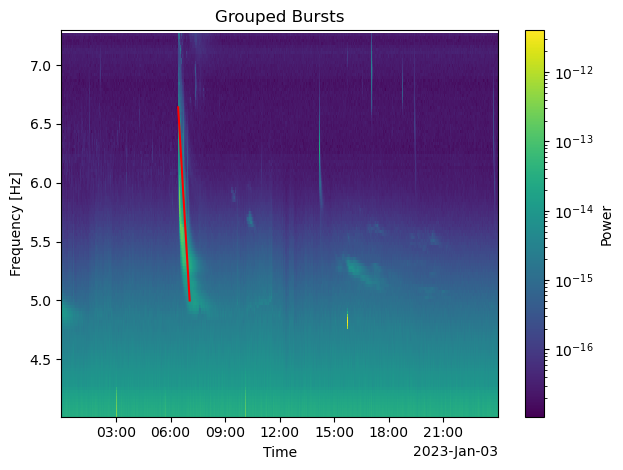

In [691]:
plt.figure(figsize=(10, 6))

fig, ax = plt.subplots()
p = ax.pcolormesh(times_hfr, freq_log_exp, new_full_data.T, norm=LogNorm())
plt.colorbar(p, label='Power')

for (x0, y0), (x1, y1) in line_sets:
    t0, t1 = t_fits[y0], t_fits[y1]
    f0, f1 = freq_log_exp[x0], freq_log_exp[x1]
    # print(t0, t1, f0, f1)
    ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

In [617]:
def hough_detect(bmap,dyspec,threshold=50,line_gap=10,line_length=25,
            theta=np.linspace(np.pi/2-np.pi/8,np.pi/2-1/180*np.pi,300)):
    # trial 6:
    # thresold = 10
    # line_gap = 50
    # line_length = 100
    # theta=np.deg2rad(np.linspace(40, 50, 120))
    
    # trial 5: logged binarization
    thresold = 50
    line_gap = 50
    line_length = 220
    theta=np.deg2rad(np.linspace(20, 30, 120))
    
    # trial 4
    # threshold = 130
    # line_gap = 110
    # line_length = 110
    # theta = np.deg2rad(np.linspace(45, 55, 120))
    
    # trial 3
    # threshold = 50
    # line_gap = 110
    # line_length = 110
    # theta = np.deg2rad(np.linspace(65, 75, 120))
    lines = probabilistic_hough_line(bmap, threshold=threshold,line_gap=line_gap,line_length=line_length,
                                 theta=theta)
    return lines

lines = hough_detect(bmap_row_mean, new_full_data)
print(lines)
print()
print('line set:')
line_sets = line_grouping_new(lines, 30, 50)
line_sets

[((39, 3549), (126, 3308)), ((39, 3546), (126, 3306)), ((39, 3550), (126, 3310)), ((39, 3544), (126, 3304)), ((39, 3541), (125, 3305)), ((38, 3563), (126, 3334)), ((38, 3565), (126, 3336)), ((39, 3539), (124, 3304)), ((40, 3556), (126, 3321)), ((40, 3524), (120, 3304)), ((40, 3525), (121, 3304)), ((38, 3573), (126, 3348)), ((39, 3533), (123, 3304)), ((39, 3558), (126, 3326)), ((38, 3570), (126, 3345)), ((40, 3527), (122, 3304)), ((38, 3588), (126, 3344)), ((38, 3579), (125, 3358)), ((38, 3590), (122, 3360)), ((39, 3551), (126, 3317)), ((39, 3536), (120, 3314)), ((38, 3581), (126, 3339)), ((38, 3576), (126, 3351)), ((40, 3537), (125, 3304)), ((38, 3583), (126, 3340)), ((39, 3556), (126, 3315)), ((40, 3554), (126, 3319)), ((39, 3528), (120, 3308)), ((39, 3553), (126, 3333))]

line set:


[((40, 3544), (125, 3312))]

<Figure size 1000x600 with 0 Axes>

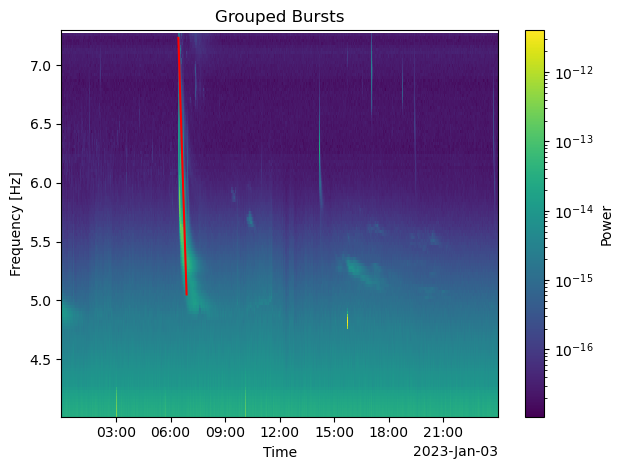

In [619]:
plt.figure(figsize=(10, 6))

fig, ax = plt.subplots()
p = ax.pcolormesh(times_hfr, freq_log_exp, new_full_data.T, norm=LogNorm())
plt.colorbar(p, label='Power')

for (x0, y0), (x1, y1) in line_sets:
    t0, t1 = t_fits[y0], t_fits[y1]
    f0, f1 = freq_log_exp[x0], freq_log_exp[x1]
    # print(t0, t1, f0, f1)
    ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()